# 📊 **AP Statistics — Unit 1**
## 🟦 Lesson 2: Exploring Categorical Data

> ### 💭 Investigation Question
> **How can we summarize and compare hundreds of categorical responses?**

---

Imagine asking **600 students**:

> **“What is your preferred way to study?”**

Reading 600 individual answers would make it difficult to see the overall pattern.

In this lesson, we will transform:

> **Raw Categories → Counts → Proportions → Graphs → Comparisons → Conclusions**

## 🎯 Learning Goals

By the end of this investigation, you will be able to:

- Construct a **frequency table** for a categorical variable.
- Calculate and interpret **relative frequencies, proportions, and percentages**.
- Construct and interpret **bar charts**.
- Construct and interpret **pie charts**.
- Use categorical data to **justify claims in context**.
- Compare the same categorical variable across **two or more groups**.
- Decide when **frequency** or **relative frequency** is more appropriate.

# 📂 Meet the Data

We will work with a simulated dataset containing **600 student observations**.

Each **row** represents one student.

Each **column** represents a characteristic recorded for that student.

The dataset contains:

| Variable | Description | Type |
|---|---|---|
| `Student_ID` | Anonymous student number | Identifier |
| `Grade_Level` | Grade 9, 10, 11, or 12 | Categorical |
| `Preferred_Study_Method` | Preferred way of studying | Categorical |
| `Transport_To_School` | Main transportation method | Categorical |
| `Favorite_Subject` | Favorite school subject | Categorical |
| `After_School_Activity` | Main after-school activity | Categorical |

Unlike quantitative data, these categories are **labels**, not numerical measurements.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reproducible simulated student dataset
rng = np.random.default_rng(42)
n = 600

grades = rng.choice(
    ["Grade 9", "Grade 10", "Grade 11", "Grade 12"],
    size=n,
    p=[0.30, 0.27, 0.23, 0.20]
)

# Make study preferences differ somewhat by grade so later comparisons are meaningful.
study_methods = []
study_probs = {
    "Grade 9":  [0.25, 0.25, 0.25, 0.15, 0.10],
    "Grade 10": [0.30, 0.20, 0.25, 0.15, 0.10],
    "Grade 11": [0.38, 0.18, 0.20, 0.14, 0.10],
    "Grade 12": [0.45, 0.15, 0.18, 0.12, 0.10]
}
study_categories = [
    "Independent Study", "Group Study", "Video Lessons",
    "Online Practice", "Tutoring"
]

for grade in grades:
    study_methods.append(
        rng.choice(study_categories, p=study_probs[grade])
    )

df = pd.DataFrame({
    "Student_ID": np.arange(1001, 1001+n),
    "Grade_Level": grades,
    "Preferred_Study_Method": study_methods,
    "Transport_To_School": rng.choice(
        ["Car", "School Bus", "Walking", "Public Transport"],
        size=n, p=[0.46, 0.32, 0.12, 0.10]
    ),
    "Favorite_Subject": rng.choice(
        ["Mathematics", "Science", "English", "Social Studies", "Technology"],
        size=n, p=[0.24, 0.23, 0.18, 0.15, 0.20]
    ),
    "After_School_Activity": rng.choice(
        ["Sports", "Study", "Gaming", "Family Time", "Clubs"],
        size=n, p=[0.26, 0.25, 0.19, 0.18, 0.12]
    )
})

print(f"Number of observations: {len(df)}")
display(df.head(10))

Number of observations: 600


,Student_ID,Grade_Level,Preferred_Study_Method,Transport_To_School,Favorite_Subject,After_School_Activity
0,1001,Grade 11,Group Study,School Bus,English,Gaming
1,1002,Grade 10,Online Practice,School Bus,English,Family Time
2,1003,Grade 12,Tutoring,Walking,Mathematics,Family Time
3,1004,Grade 11,Video Lessons,School Bus,Social Studies,Clubs
4,1005,Grade 9,Tutoring,Car,Social Studies,Family Time
5,1006,Grade 12,Online Practice,Car,Social Studies,Sports
6,1007,Grade 11,Online Practice,School Bus,Mathematics,Gaming
7,1008,Grade 11,Independent Study,School Bus,Science,Study
8,1009,Grade 9,Video Lessons,Car,Science,Study
9,1010,Grade 10,Group Study,Car,Mathematics,Clubs


# 🔍 Our First Categorical Investigation

Our main question is:

> ### **What is the preferred study method among these students?**

Look at a few raw responses.

You might see:

`Independent Study`

`Video Lessons`

`Group Study`

`Independent Study`

`Online Practice`

`Tutoring`

With hundreds of responses, it becomes difficult to answer:

> **Which category is most common?**

For categorical data, calculating a mean or median would not make sense.

Instead, we begin by **counting how many observations belong to each category**.

In [2]:
# Look at the first 20 raw responses
display(
    df[["Student_ID", "Preferred_Study_Method"]]
    .head(20)
    .style.hide(axis="index")
)

Student_ID,Preferred_Study_Method
1001,Group Study
1002,Online Practice
1003,Tutoring
1004,Video Lessons
1005,Tutoring
1006,Online Practice
1007,Online Practice
1008,Independent Study
1009,Video Lessons
1010,Group Study


# 1️⃣ Frequency — How Many?

The **frequency** of a category is the number of observations belonging to that category.

A **frequency table** organizes these counts.

For example, if 180 students prefer Independent Study, then:

> **Frequency of Independent Study = 180 students**

Let's ask Python to count all 600 responses.

In [5]:
frequency_table = (
    df["Preferred_Study_Method"]
    .value_counts()
    .rename_axis("Study Method")
    .reset_index(name="Frequency")
)

display(frequency_table.style.hide(axis="index"))

print("Total:", frequency_table["Frequency"].sum(), "students")

Study Method,Frequency
Independent Study,199
Group Study,122
Video Lessons,122
Online Practice,94
Tutoring,63


Total: 600 students


## 🧠 What Did Python Actually Do?

Python did not calculate an average.

It looked through the **600 responses** and counted how many times each category appeared.

For example, if `Independent Study` appears 190 times:

> **190 students belong to the Independent Study category.**

This count is the **frequency**.

### ✏️ Check Your Understanding

Using the table above:

1. Which study method has the greatest frequency?
2. Which has the smallest frequency?
3. How many students are represented altogether?

# 2️⃣ Relative Frequency — What Proportion?

Frequency answers:

> **How many?**

But sometimes we want to answer:

> **What proportion of the students?**

The **relative frequency** of a category is:

$$
\text{Relative Frequency}
=
\frac{\text{Frequency of the Category}}
{\text{Total Number of Observations}}
$$

For example, if 180 of 600 students prefer Independent Study:

$$
\frac{180}{600}=0.30
$$

The relative frequency is **0.30**, which is the same as **30%**.

In [6]:
frequency_table["Relative Frequency"] = (
    frequency_table["Frequency"] / frequency_table["Frequency"].sum()
)

frequency_table["Percentage"] = (
    frequency_table["Relative Frequency"] * 100
)

display(
    frequency_table.style
    .format({
        "Relative Frequency": "{:.3f}",
        "Percentage": "{:.1f}%"
    })
    .hide(axis="index")
)

Study Method,Frequency,Relative Frequency,Percentage
Independent Study,199,0.332,33.2%
Group Study,122,0.203,20.3%
Video Lessons,122,0.203,20.3%
Online Practice,94,0.157,15.7%
Tutoring,63,0.105,10.5%


## 🔄 Proportion, Relative Frequency, Percentage, and Ratio

These are different ways of communicating the same categorical information.

Suppose **180 out of 600 students** select a category.

### Proportion / Relative Frequency

$$
\frac{180}{600}=0.30
$$

### Percentage

$$
0.30\times100=30\%
$$

### Ratio

The count can also be expressed relative to the total:

$$
180:600
$$

The form changes, but each describes the **relative size of the same category**.

# 🤔 Frequency or Relative Frequency?

For **one group**, frequencies and relative frequencies often tell a similar story.

But imagine comparing:

- a group containing **200 students**, and
- another group containing **100 students**.

If 80 students in the first group and 60 students in the second group choose the same category, which group has the stronger preference?

Looking only at counts:

> 80 > 60

But looking at proportions:

$$
\frac{80}{200}=40\%
$$

$$
\frac{60}{100}=60\%
$$

The second group actually has the **larger proportion**.

> ### 💡 When group sizes differ, relative frequencies are usually more informative for comparing distributions.

# 3️⃣ Bar Charts — Turning Categories into a Graph

A **bar chart** displays the frequency or relative frequency of each category.

Each bar represents **one category**.

The height of the bar represents:

- its **frequency**, or
- its **relative frequency**.

### ⚠️ Bar Chart vs. Histogram

These graphs may look similar, but they represent different kinds of data.

| Bar Chart | Histogram |
|---|---|
| Categorical data | Quantitative data |
| Each bar is a category | Each bar is a numerical interval |
| Bars are separated | Bars normally touch |
| Category order can often change | Numerical order matters |

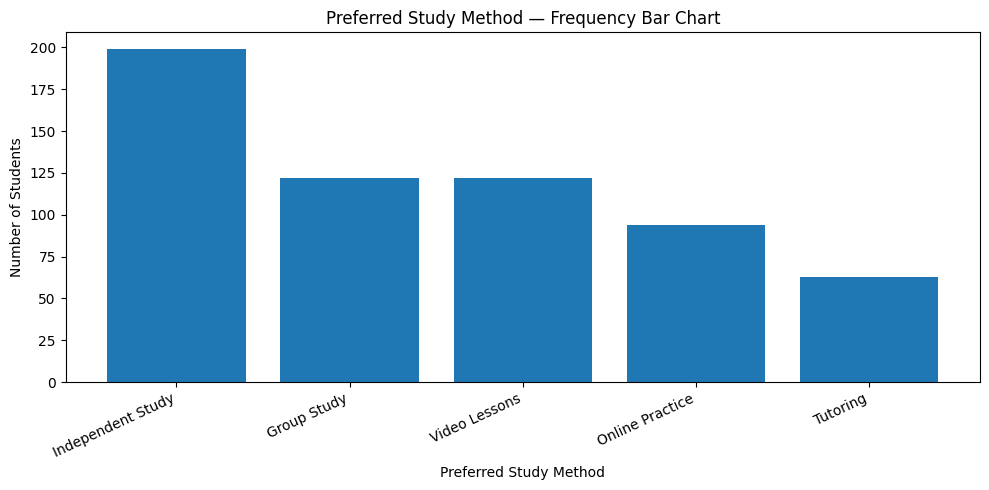

In [7]:
bar_data = frequency_table.sort_values("Frequency", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(bar_data["Study Method"], bar_data["Frequency"])
plt.xlabel("Preferred Study Method")
plt.ylabel("Number of Students")
plt.title("Preferred Study Method — Frequency Bar Chart")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## 📊 Relative-Frequency Bar Chart

We can represent the **same categorical distribution** using percentages instead of counts.

The pattern should remain the same; only the vertical scale changes.

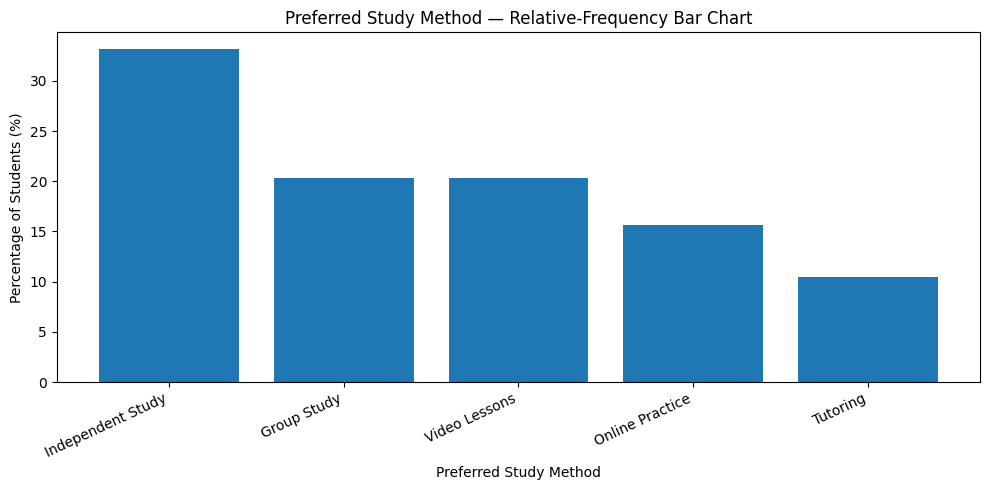

In [8]:
plt.figure(figsize=(10, 5))
plt.bar(bar_data["Study Method"], bar_data["Percentage"])
plt.xlabel("Preferred Study Method")
plt.ylabel("Percentage of Students (%)")
plt.title("Preferred Study Method — Relative-Frequency Bar Chart")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

### 🔎 Read the Bar Chart

Answer in context:

1. Which study method is most common?
2. Which is least common?
3. Approximately what percentage prefer the most common method?
4. Does changing from frequency to percentage change the overall pattern?
5. Write one statistical claim supported by the graph.

# 4️⃣ Pie Charts — Parts of a Whole

A **pie chart** represents the entire dataset as a circle.

Each slice represents a category.

The size of each slice corresponds to that category's **relative frequency**.

All slices together represent:

$$
1=100\%
$$

So if a category contains 30% of the observations, its slice represents 30% of the circle.

## 🥧 From Percentage to Degrees in a Pie Chart

A pie chart represents the entire dataset as a **circle**.

A complete circle contains:

$$
360^\circ
$$

and the entire dataset represents:

$$
100\%
$$

Therefore, to convert a percentage into the angle of a pie-chart slice, we use:

$$
\text{Angle}=
\frac{\text{Percentage}}{100}\times360^\circ
$$

Since relative frequency is written as a decimal, we can also use:

$$
\text{Angle}=
\text{Relative Frequency}\times360^\circ
$$

---

### ✏️ Example

Suppose **30%** of students prefer Independent Study.

The angle of this category in the pie chart is:

$$
\text{Angle}
=
\frac{30}{100}\times360^\circ
$$

$$
\text{Angle}=108^\circ
$$

So **30% of the students corresponds to a 108° slice** of the pie chart.

---

### 🔄 Going the Other Way

If we know the angle and want to find the percentage:

$$
\text{Percentage}
=
\frac{\text{Angle}}{360^\circ}\times100
$$

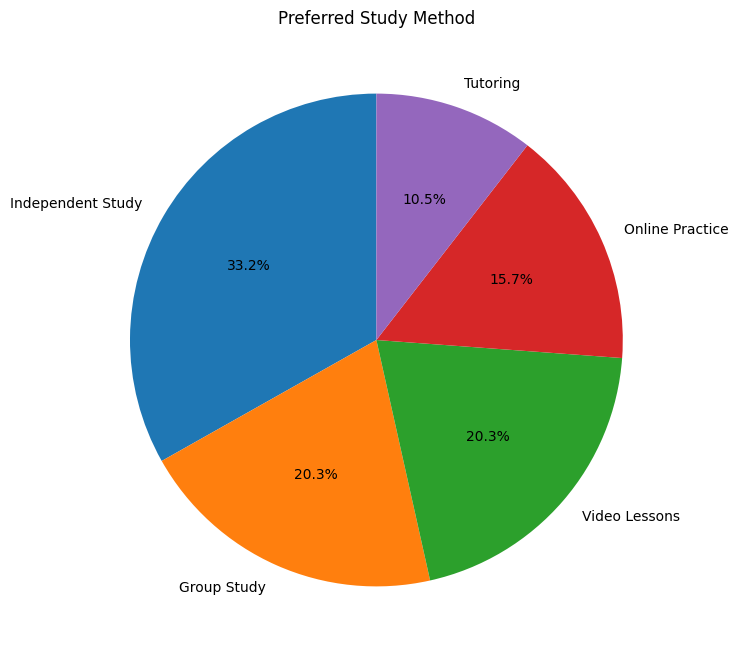

In [9]:
plt.figure(figsize=(8, 8))
plt.pie(
    bar_data["Frequency"],
    labels=bar_data["Study Method"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Preferred Study Method")
plt.show()

## 🤔 Bar Chart or Pie Chart?

Both graphs display the **same categorical distribution**, but they emphasize different things.

A **bar chart** makes the heights of categories easy to compare.

A **pie chart** emphasizes how each category contributes to the **whole**.

### Discuss

1. Which graph makes it easier to identify the largest category?
2. Which makes the idea of “part of the whole” clearer?
3. If two categories have very similar percentages, which display makes the difference easier to see?

# 5️⃣ From Graphs to Statistical Claims

Creating a graph is not the final goal.

In AP Statistics, we use data to **support conclusions in context**.

Suppose we claim:

> **Independent Study is the most commonly preferred study method among students in this dataset.**

A strong justification should include **evidence**.

For example:

> Independent Study was selected by ___ of the 600 students, or approximately ___%, which is greater than the proportion selecting any other study method.

Notice the structure:

> ### **Claim → Statistical Evidence → Context**

In [10]:
top = frequency_table.iloc[0]

print("Most common category:", top["Study Method"])
print("Frequency:", int(top["Frequency"]))
print(f"Percentage: {top['Percentage']:.1f}%")

Most common category: Independent Study
Frequency: 199
Percentage: 33.2%


# 6️⃣ Comparing Categorical Distributions

Now let's move beyond describing only one group.

We will investigate:

> ### **Do preferred study methods differ across grade levels?**

The variable being studied is still:

**Preferred Study Method**

But now we will compare its distribution across different **grade-level groups**.

## 📋 Start with Counts

A two-way frequency table can show the number of students in each combination of categories.

The rows will represent **grade level**.

The columns will represent **preferred study method**.

In [11]:
grade_counts = pd.crosstab(
    df["Grade_Level"],
    df["Preferred_Study_Method"]
)

display(grade_counts)

Preferred_Study_Method,Group Study,Independent Study,Online Practice,Tutoring,Video Lessons
Grade_Level,,,,,
Grade 10,32,46,31,19,28
Grade 11,29,57,23,15,25
Grade 12,14,53,17,10,20
Grade 9,47,43,23,19,49


## ⚠️ Is Comparing Counts Enough?

Not necessarily.

The grade levels may contain **different numbers of students**.

A grade with more students could have larger counts simply because the group itself is larger.

To compare the distributions fairly, we should examine **relative frequencies within each grade**.

In [12]:
grade_relative = pd.crosstab(
    df["Grade_Level"],
    df["Preferred_Study_Method"],
    normalize="index"
)

grade_percent = grade_relative * 100

display(
    grade_percent.style
    .format("{:.1f}%")
)

Preferred_Study_Method,Group Study,Independent Study,Online Practice,Tutoring,Video Lessons
Grade_Level,,,,,
Grade 10,20.5%,29.5%,19.9%,12.2%,17.9%
Grade 11,19.5%,38.3%,15.4%,10.1%,16.8%
Grade 12,12.3%,46.5%,14.9%,8.8%,17.5%
Grade 9,26.0%,23.8%,12.7%,10.5%,27.1%


# 📊 Comparing Groups with Relative-Frequency Bar Charts

Now each grade's percentages add to approximately **100%**.

This allows us to compare the **distribution of study preferences**, rather than simply comparing group sizes.

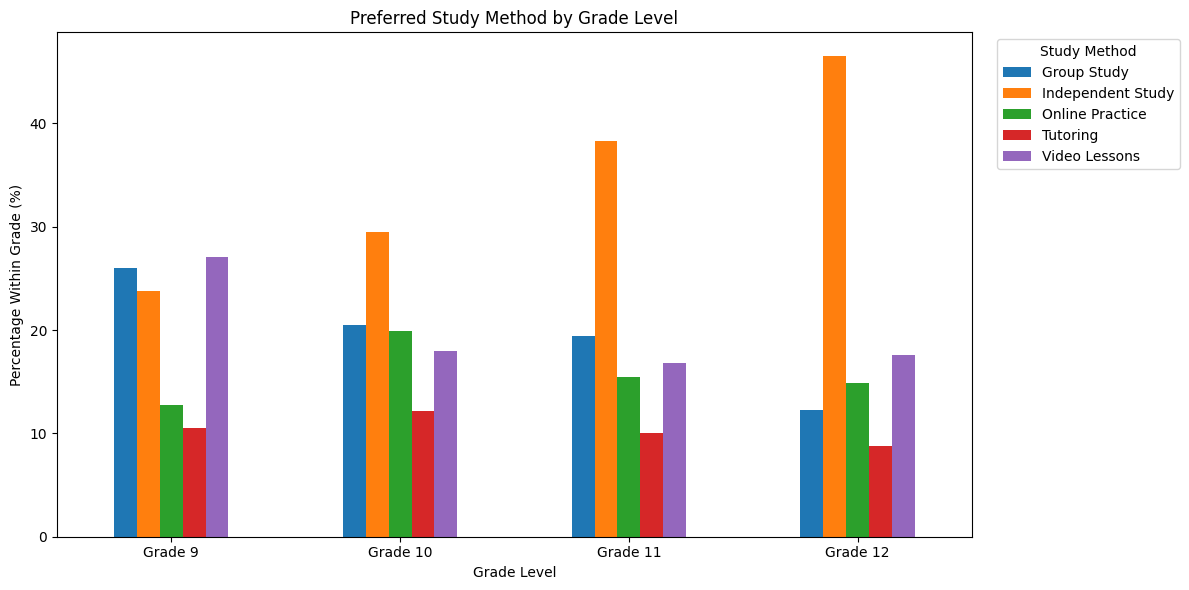

In [13]:
grade_order = ["Grade 9", "Grade 10", "Grade 11", "Grade 12"]
grade_percent = grade_percent.reindex(grade_order)

ax = grade_percent.plot(
    kind="bar",
    figsize=(12, 6)
)

ax.set_xlabel("Grade Level")
ax.set_ylabel("Percentage Within Grade (%)")
ax.set_title("Preferred Study Method by Grade Level")
plt.xticks(rotation=0)
plt.legend(title="Study Method", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 🔎 Compare the Distributions

Use the relative-frequency table and bar chart.

Answer:

1. Which study method is most common in Grade 9?
2. Which is most common in Grade 12?
3. Which study preference changes the most across grade levels?
4. Are there categories with similar relative frequencies across the grades?
5. Write one sentence that **directly compares** two grade levels.

### Strong comparison language

Instead of:

> “Grade 9 has 25% and Grade 12 has 45%.”

Write:

> “A larger proportion of Grade 12 students prefer independent study than Grade 9 students.”

Then support the comparison with the actual percentages.

# 🧠 Important Ideas from Categorical Data

Before finishing, make sure you can distinguish these ideas:

### Frequency
The **number** of observations in a category.

### Relative Frequency
The **proportion** of observations in a category.

### Percentage

$$
\text{Percentage}=\text{Relative Frequency}\times100
$$

### Bar Chart
Displays frequencies or relative frequencies for categories.

### Pie Chart
Displays categories as proportions of a whole.

### Comparing Groups
When group sizes differ, compare **relative frequencies**, not just raw counts.

### Statistical Communication
A conclusion should be written **in context** and supported by numerical or graphical evidence.

# 🏁 Final Categorical Data Investigation

Choose **one categorical variable** from the dataset:

- `Transport_To_School`
- `Favorite_Subject`
- `After_School_Activity`

Prepare a short statistical report.

## Your report should:

1. Construct a **frequency table**.
2. Calculate **relative frequencies and percentages**.
3. Create an appropriate **bar chart**.
4. Create a **pie chart**.
5. Identify the most and least common categories.
6. Write at least **two statistical conclusions in context**.
7. Compare the distribution across **two or more grade levels** using relative frequencies.
8. Support your comparison with numerical or graphical evidence.

> ### Remember:
> The goal is not simply to produce tables and graphs.
>
> The goal is to use them to **understand, compare, and communicate what the categorical data tells us**.